In [2]:
from matplotlib import pyplot as plt
import numpy as np
import os
import glob
from scipy.interpolate import PchipInterpolator,interp1d
from scipy.integrate import quad
from scipy.stats import linregress
import kuibit.simdir as SD
import re
import h5py as h5


In [3]:
eos_colors = {"BA": "red",
              "DD2F-SF1": "black",
              "DD2": "orange",
              "BHBlp": "green",
              "SFHo": "purple",
              "BLQ": "gold",
              "SLy4": "turquoise",
              "DD2F": "slategray",
              "BLh": "darkgreen",
              "LS220": "plum",
              }

In [29]:
rmft_colors = ["Red","Blue","Black","Purple"]

Text(0, 0.5, 'Mass ($M_{\\odot}$)')

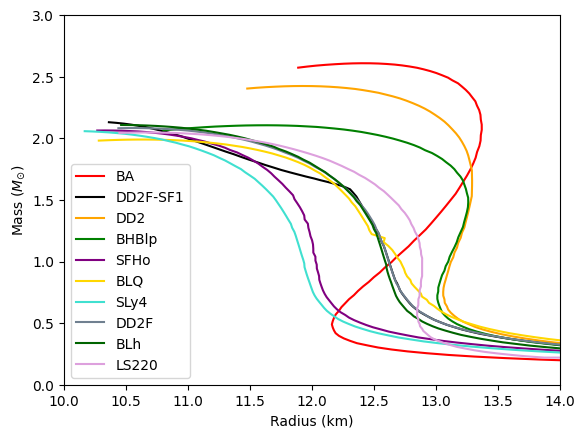

In [12]:
for eos in eos_colors:
    mvr_data = np.loadtxt(f'./Figure_Data/EOS/MVR/CORE/{eos}_MVR.txt')
    plt.plot(mvr_data[:,1],mvr_data[:,0],color=eos_colors[eos],label=eos)
plt.legend()
plt.gca().set_xlim([10,14])
plt.gca().set_ylim([0,3.0])
plt.gca().set_xlabel(r'Radius (km)')
plt.gca().set_ylabel(r'Mass ($M_{\odot}$)')
    

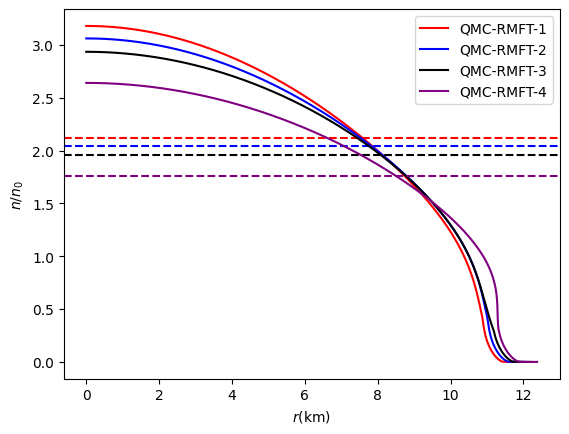

In [39]:
rmft_dens_data = [None,None,None,None]
rmft_stop = [0,0,0,0]


for i in range(4):
    rmft_dens_data[i] = np.loadtxt(f'./Figure_Data/CORE/RMFT_Density_Profile/RMFT{i+1}_density.txt')
    rmft_stop[i] = (float(rmft_dens_data[i][0,1])/0.16)*(2.0/3.0)
    plt.plot(rmft_dens_data[i][:,0],rmft_dens_data[i][:,1]/0.16,color = rmft_colors[i],label=f'QMC-RMFT-{i+1}')
    plt.axhline(y = rmft_stop[i],color=rmft_colors[i],linestyle='--')
plt.gca().set_ylabel(r"$n/n_0$")
plt.gca().set_xlabel(r"$r (\text{km})$")
plt.legend()
plt.savefig('./Figures/Final_Paper_Figs/RMFT_nb_vs_r.pdf',format = 'pdf',dpi = 300)


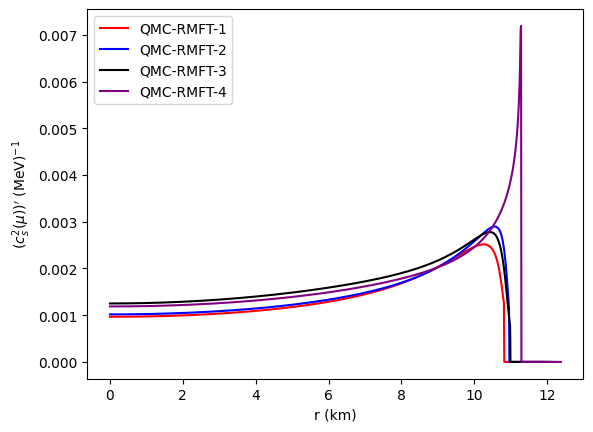

In [38]:
for i in range(4):
    prof_rmft = np.loadtxt(f"./Figure_Data/CORE/RMFT_Alpha_Profile/RMFT_{i+1}_alpha.txt")
    plt.plot(prof_rmft[:,0],prof_rmft[:,1],label=f'QMC-RMFT-{i+1}',color=rmft_colors[i])
plt.gca().set_xlabel('r (km)')
plt.gca().set_ylabel(r"$(c_s^2 (\mu))' \text{ (MeV)}^{-1}$")
plt.legend()
plt.savefig('./Figures/Final_Paper_Figs/RMFT_cs2prime_vs_r.pdf',format='pdf',dpi = 300)
